# Vaccines Overview


In [1]:
import pandas as pd

In [6]:
df = pd.read_csv(r'C:\Users\ThinkPad\Desktop\Mastermind\WHO\WHO_health_indicators\CSV_files\WHS2025_DATADOWNLOAD.csv')
indicator_list=pd.read_csv(r'C:\Users\ThinkPad\Desktop\Mastermind\WHO\WHO_health_indicators\CSV_files\indicator_list.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9729 entries, 0 to 9728
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IndicatorName   9729 non-null   str    
 1   IndicatorCode   9729 non-null   str    
 2   Location        9729 non-null   str    
 3   LocationCode    9729 non-null   str    
 4   Year            9729 non-null   str    
 5   Disaggregation  1517 non-null   str    
 6   NumericValue    9665 non-null   float64
 7   DisplayValue    9727 non-null   str    
 8   Comments        2722 non-null   str    
dtypes: float64(1), str(8)
memory usage: 684.2 KB


### Creating a df with only vaccine indicators

In [20]:
mask = df['IndicatorName'].str.contains(r'vaccine|immunization', case=False, na=False)
vaccine_df = df[mask].copy()
vaccine_df["IndicatorName"].unique()
vaccine_df.to_csv(r'C:\Users\ThinkPad\Desktop\Mastermind\WHO\WHO_health_indicators\CSV_files\vaccine_indicators.csv', index=False)
vaccine_df.info()

<class 'pandas.DataFrame'>
Index: 703 entries, 2039 to 5749
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IndicatorName   703 non-null    str    
 1   IndicatorCode   703 non-null    str    
 2   Location        703 non-null    str    
 3   LocationCode    703 non-null    str    
 4   Year            703 non-null    str    
 5   Disaggregation  0 non-null      str    
 6   NumericValue    703 non-null    float64
 7   DisplayValue    703 non-null    str    
 8   Comments        0 non-null      str    
dtypes: float64(1), str(8)
memory usage: 54.9 KB


In [24]:
vaccine_df["Year"].unique()

<StringArray>
['2023']
Length: 1, dtype: str

### -> the entire dataset for vaccines is about the year 2023

c:\Users\ThinkPad\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 24.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\ThinkPad\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\ThinkPad\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\ThinkPad\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 24.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


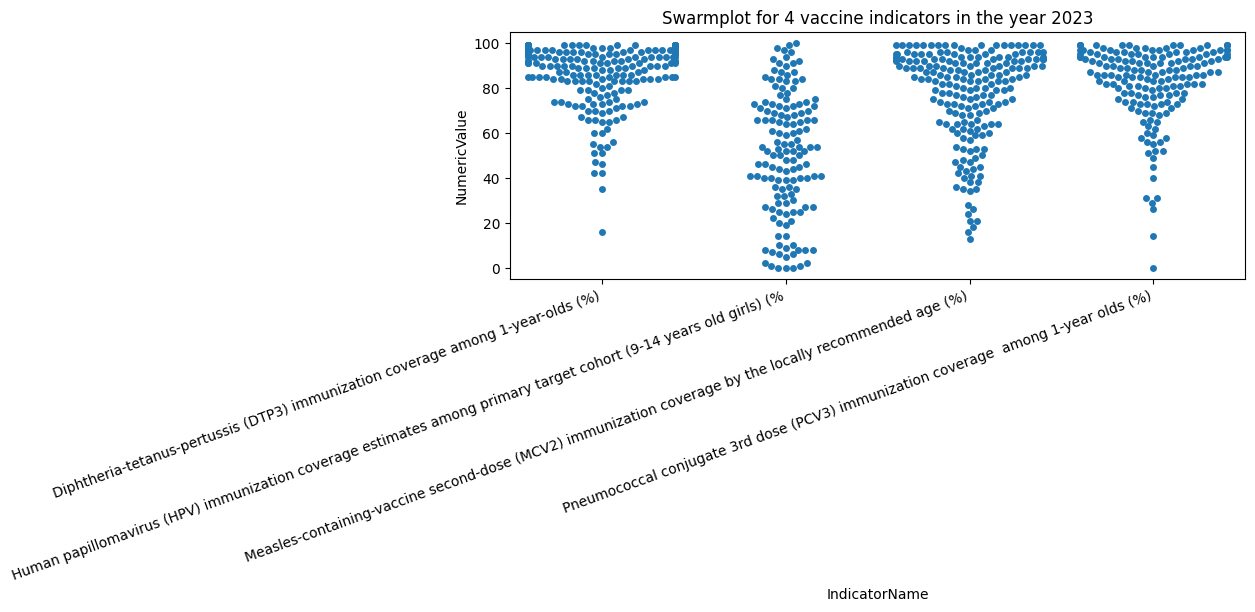

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.swarmplot(data=vaccine_df, x='IndicatorName', y='NumericValue')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.title("Swarmplot for 4 vaccine indicators in the year 2023")
plt.savefig('vaccine_swarmplot_4_indicators.png', dpi=300, bbox_inches='tight')
plt.show()

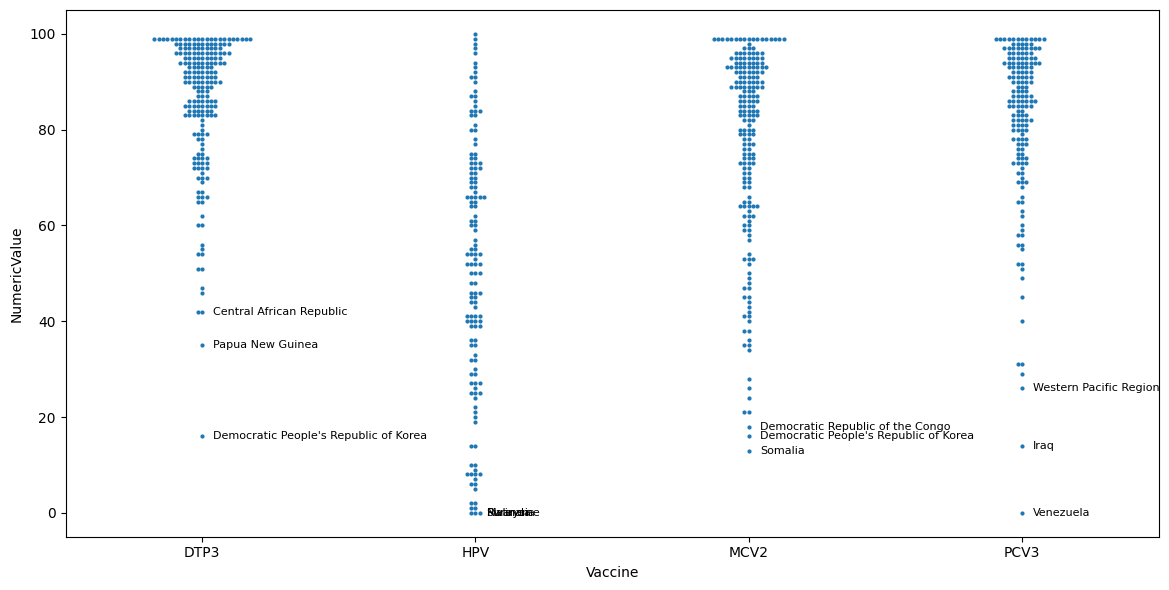

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

vaccine_df['Location'] = vaccine_df['Location'].replace(
    'Venezuela (Bolivarian Republic of)', 'Venezuela'
)
short = {
    'Diphtheria-tetanus-pertussis (DTP3) immunization coverage among 1-year-olds (%)': 'DTP3',
    'Human papillomavirus (HPV) immunization coverage estimates among primary target cohort (9-14 years old girls) (%': 'HPV',  # no closing )
    'Measles-containing-vaccine second-dose (MCV2) immunization coverage by the locally recommended age (%)': 'MCV2',
    'Pneumococcal conjugate 3rd dose (PCV3) immunization coverage  among 1-year olds (%)': 'PCV3',
}
vaccine_df['Vaccine'] = vaccine_df['IndicatorName'].map(short)
order = ['DTP3', 'HPV', 'MCV2', 'PCV3']

plt.figure(figsize=(12, 6))
ax = sns.swarmplot(data=vaccine_df, x='Vaccine', y='NumericValue', order=order, size=3)

for i, cat in enumerate(order):
    lowest3 = vaccine_df[vaccine_df['Vaccine'] == cat].nsmallest(3, 'NumericValue')
    for _, row in lowest3.iterrows():
        ax.annotate(
            row['Location'],
            xy=(i, row['NumericValue']),
            xytext=(8, 0),
            textcoords='offset points',
            fontsize=8,
            va='center',
        )

plt.tight_layout()
plt.savefig('vaccine_swarmplot.png', dpi=300, bbox_inches='tight')
plt.show()

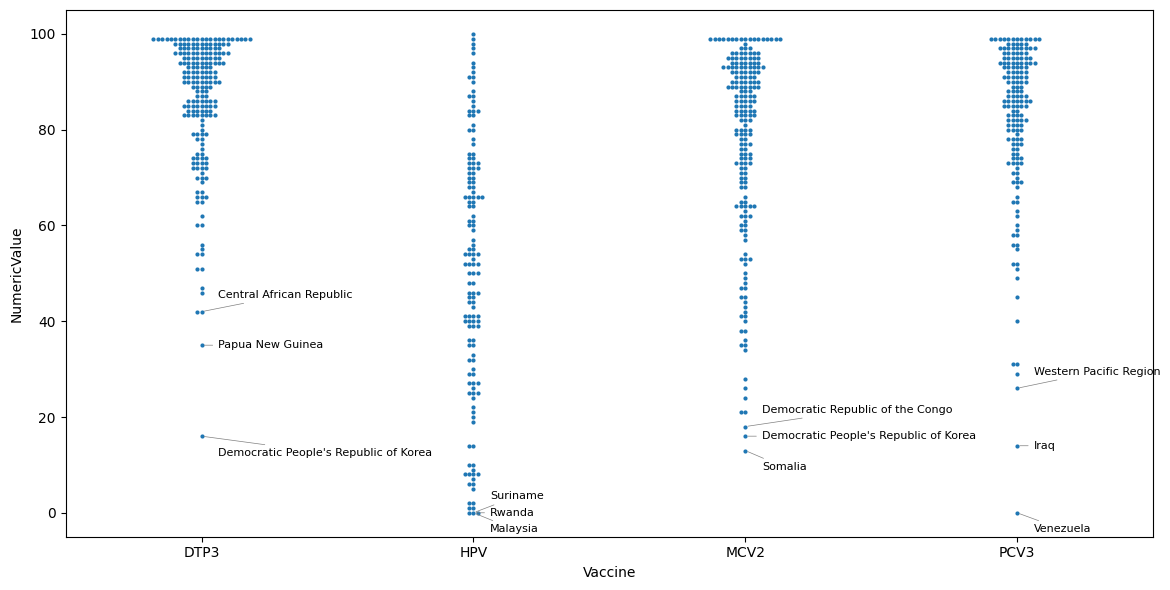

In [32]:
import os

os.makedirs('Plot_pictures', exist_ok=True)

vaccine_df['LocationShort'] = vaccine_df['Location'].str.replace(r'\s*\(.*\)', '', regex=True)

plt.figure(figsize=(12, 6))
ax = sns.swarmplot(data=vaccine_df, x='Vaccine', y='NumericValue', order=order, size=3)

for i, cat in enumerate(order):
    lowest3 = (vaccine_df[vaccine_df['Vaccine'] == cat]
               .nsmallest(3, 'NumericValue')
               .reset_index(drop=True))
    for j, row in lowest3.iterrows():
        ax.annotate(
            row['LocationShort'],
            xy=(i, row['NumericValue']),
            xytext=(12, (j - 1) * 12),   # spread vertically: -12, 0, +12 px
            textcoords='offset points',
            fontsize=8,
            va='center',
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
        )

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_swarmplot.png', dpi=300, bbox_inches='tight')
plt.show()

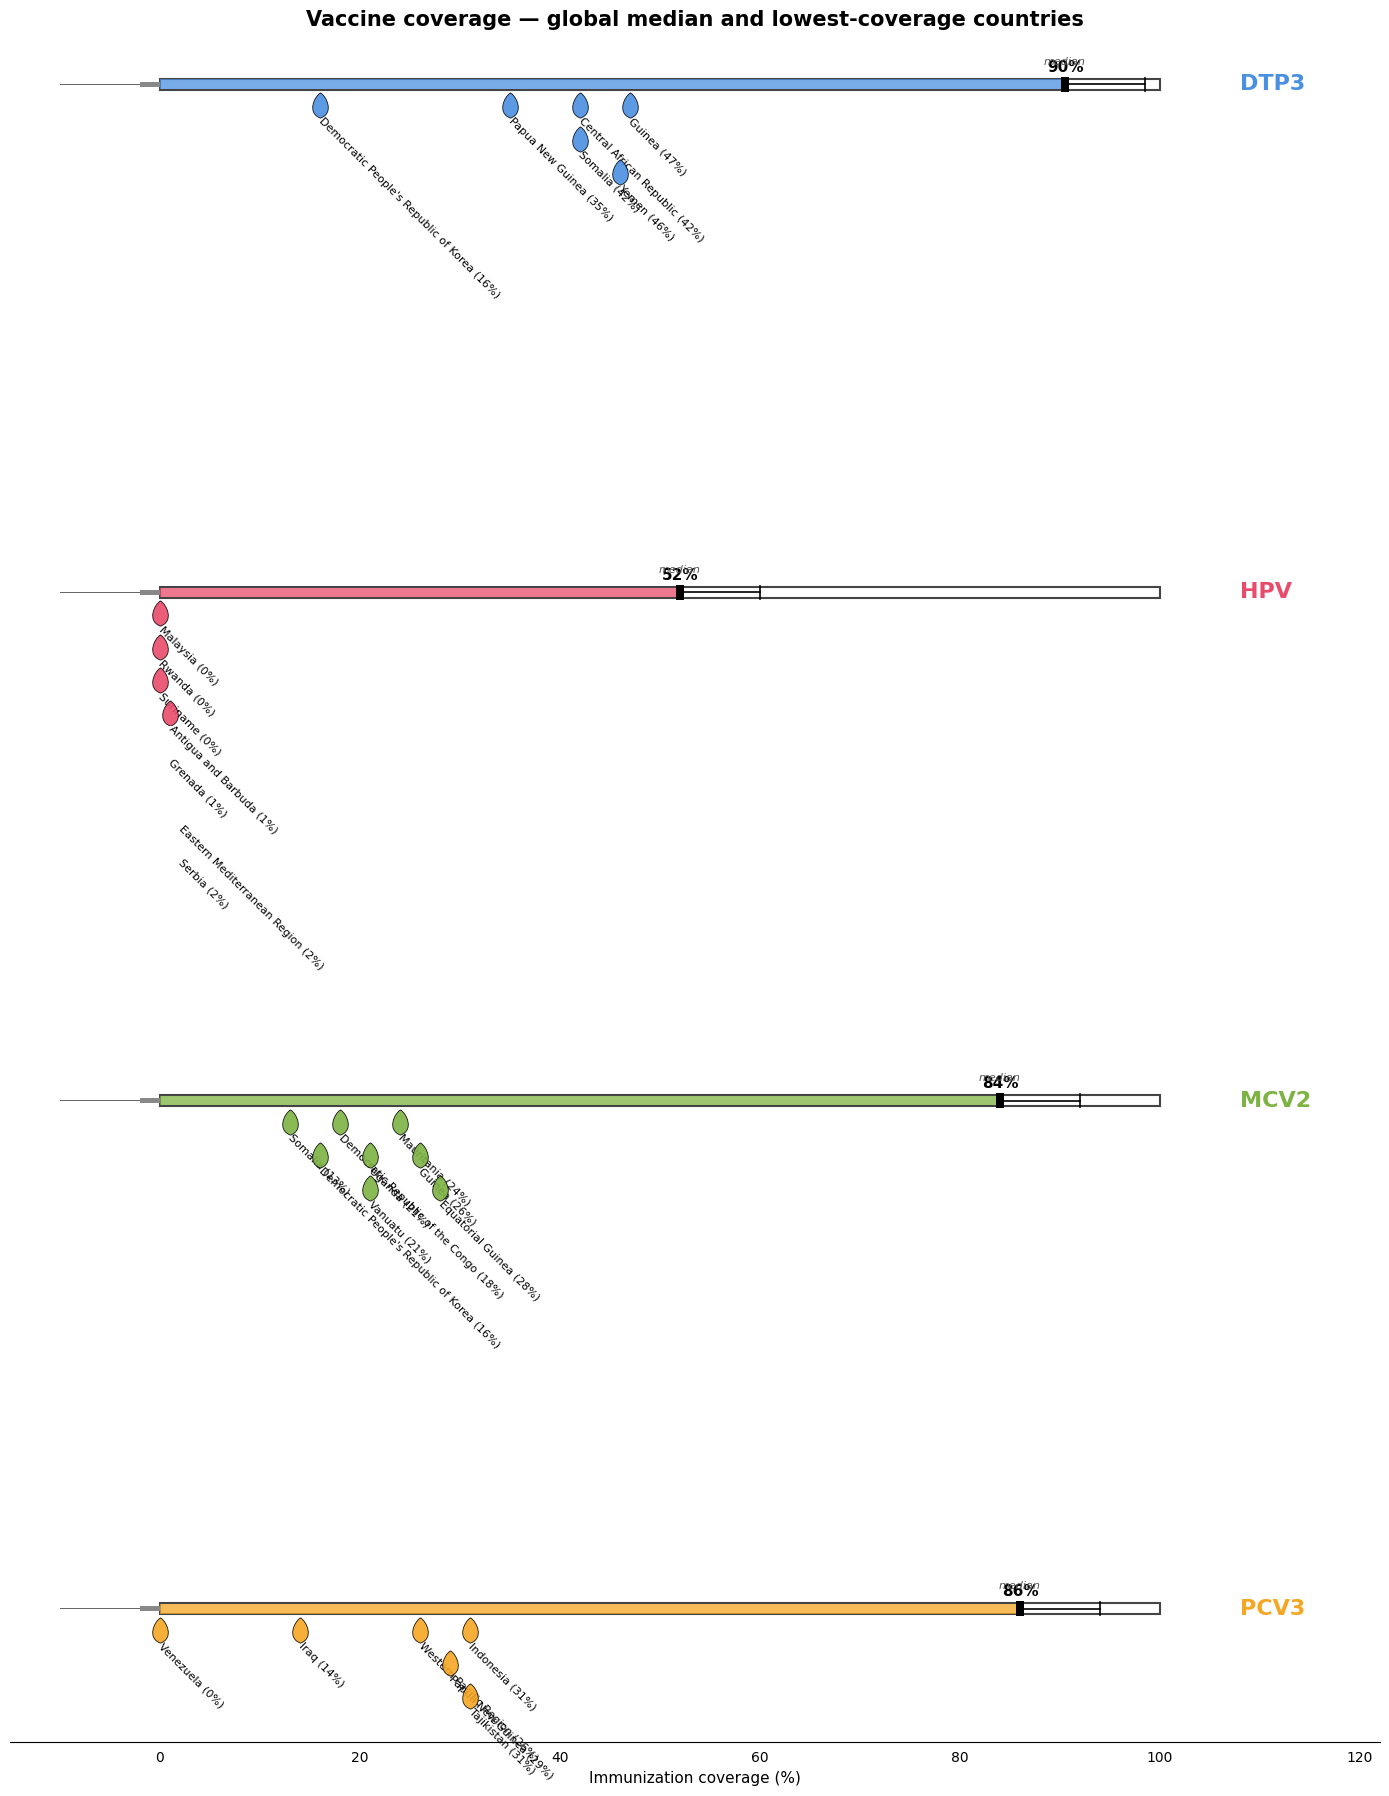

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import os

os.makedirs('Plot_pictures', exist_ok=True)

# Classic teardrop: pointed at top, round bulb at bottom
DROP = Path(
    [(0, 1.0),
     (0.5, 0.7), (1.1, -0.6), (0, -1.0),
     (-1.1, -0.6), (-0.5, 0.7), (0, 1.0)],
    [Path.MOVETO] + [Path.CURVE4]*6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
n_drops = {'DTP3': 6, 'HPV': 7, 'MCV2': 8, 'PCV3': 6}

fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)

for ax, vaccine, color in zip(axes, order, colors):
    sub = vaccine_df[vaccine_df['Vaccine'] == vaccine].dropna(subset=['NumericValue'])
    median = sub['NumericValue'].median()
    bottom_n = (sub.nsmallest(n_drops[vaccine], 'NumericValue')
                .sort_values('NumericValue').reset_index(drop=True))

    barrel_h = 0.5
    by = 0
    needle_tip_x = -10

    # Needle
    ax.add_patch(patches.Polygon(
        [[needle_tip_x, by + 0.03], [-2, by + 0.03],
         [-2, by - 0.03], [needle_tip_x, by - 0.03]],
        facecolor='#666', zorder=3))
    ax.add_patch(patches.Rectangle((-2, by - 0.12), 2, 0.24,
                                   facecolor='#888', zorder=3))
    # Barrel + fill
    ax.add_patch(patches.Rectangle((0, by - barrel_h/2), 100, barrel_h,
                                   linewidth=1.5, edgecolor='#444',
                                   facecolor='white', zorder=2))
    ax.add_patch(patches.Rectangle((0, by - barrel_h/2 + 0.03), median, barrel_h - 0.06,
                                   facecolor=color, alpha=0.75, zorder=2.5))
    # Plunger (median bar + narrow lines)
    ax.add_patch(patches.Rectangle((median - 0.4, by - barrel_h/2 - 0.08),
                                   0.8, barrel_h + 0.16,
                                   facecolor='black', zorder=4))
    ax.plot([median + 0.4, median + 8.0], [by, by],
            color='black', lw=1.2, zorder=4)
    ax.plot([median + 8.0, median + 8.0],
            [by - barrel_h/2 - 0.05, by + barrel_h/2 + 0.05],
            color='black', lw=1.2, zorder=4)
    # Median label
    ax.text(median, by + barrel_h/2 + 0.18, f'{median:.0f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')
    ax.text(median, by + barrel_h/2 + 0.55, 'median',
            ha='center', va='bottom', fontsize=8, color='#555', style='italic')

    # Drops placed at x = value; stack vertically if values collide
    base_y = by - barrel_h/2 - 0.7
    positions = []
    for _, row in bottom_n.iterrows():
        x = row['NumericValue']
        drop_y = base_y
        while any(abs(x - px) < 5 and abs(drop_y - py) < 1.5 for px, py in positions):
            drop_y -= 1.5
        positions.append((x, drop_y))

        ax.scatter(x, drop_y, s=400, marker=DROP, color=color, alpha=0.9,
                   edgecolor='black', linewidth=0.6, zorder=5)
        ax.text(x - 0.3, drop_y - 0.5,
                f"{row['LocationShort']} ({row['NumericValue']:.0f}%)",
                rotation=-45, ha='left', va='top', fontsize=8)

    # Vaccine name
    ax.text(108, by, vaccine, fontsize=16, fontweight='bold',
            va='center', ha='left', color=color)

    ax.set_xlim(-15, 122)
    ax.set_ylim(-6.0, 1.5)
    ax.set_yticks([])
    for s in ['left', 'right', 'top']:
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelbottom=False)

axes[-1].tick_params(labelbottom=True)
axes[-1].spines['bottom'].set_visible(True)
axes[-1].set_xlabel('Immunization coverage (%)', fontsize=11)

fig.suptitle('Vaccine coverage — global median and lowest-coverage countries',
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_syringes.png', dpi=300, bbox_inches='tight')
plt.show()
                       


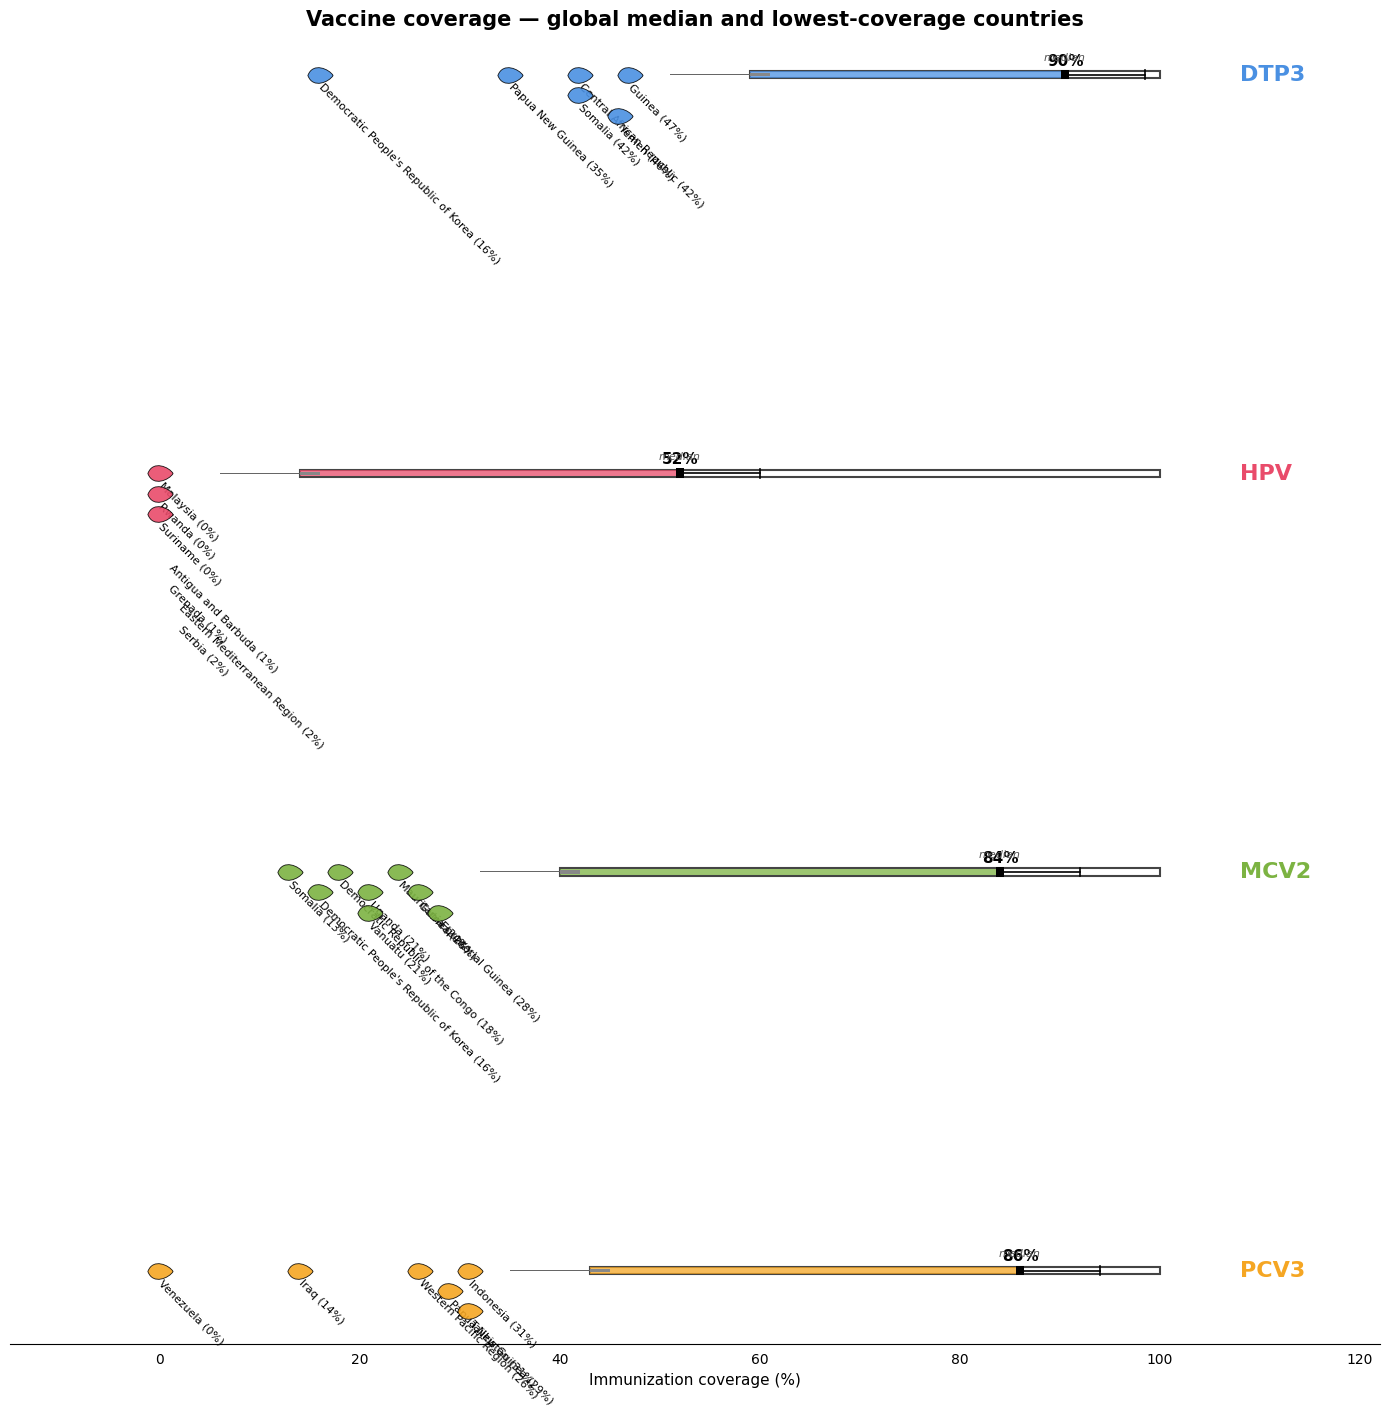

In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import os

os.makedirs('Plot_pictures', exist_ok=True)

# Teardrop rotated 90° CW (tip points right, toward the syringe)
DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4]*6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
n_drops = {'DTP3': 6, 'HPV': 7, 'MCV2': 8, 'PCV3': 6}

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

for ax, vaccine, color in zip(axes, order, colors):
    sub = vaccine_df[vaccine_df['Vaccine'] == vaccine].dropna(subset=['NumericValue'])
    median = sub['NumericValue'].median()
    bottom_n = (sub.nsmallest(n_drops[vaccine], 'NumericValue')
                .sort_values('NumericValue').reset_index(drop=True))
    max_bottom = bottom_n['NumericValue'].max()

    barrel_h = 0.5
    by = 0
    # Syringe placed to the right of the worst-performer drops
    needle_tip_x = max_bottom + 4
    barrel_left = needle_tip_x + 8
    barrel_right = 100
    barrel_width = barrel_right - barrel_left

    # --- Needle ---
    ax.add_patch(patches.Polygon(
        [[needle_tip_x, by + 0.03], [barrel_left, by + 0.03],
         [barrel_left, by - 0.03], [needle_tip_x, by - 0.03]],
        facecolor='#666', zorder=3))
    ax.add_patch(patches.Rectangle((barrel_left, by - 0.12), 2, 0.24,
                                   facecolor='#888', zorder=3))

    # --- Barrel ---
    ax.add_patch(patches.Rectangle((barrel_left, by - barrel_h/2), barrel_width, barrel_h,
                                   linewidth=1.5, edgecolor='#444',
                                   facecolor='white', zorder=2))
    fill_width = max(0, median - barrel_left)
    ax.add_patch(patches.Rectangle((barrel_left, by - barrel_h/2 + 0.03),
                                   fill_width, barrel_h - 0.06,
                                   facecolor=color, alpha=0.75, zorder=2.5))

    # --- Plunger: median bar + narrow lines for rod & thumb ---
    ax.add_patch(patches.Rectangle((median - 0.4, by - barrel_h/2 - 0.08),
                                   0.8, barrel_h + 0.16,
                                   facecolor='black', zorder=4))
    ax.plot([median + 0.4, median + 8.0], [by, by],
            color='black', lw=1.2, zorder=4)
    ax.plot([median + 8.0, median + 8.0],
            [by - barrel_h/2 - 0.05, by + barrel_h/2 + 0.05],
            color='black', lw=1.2, zorder=4)

    # --- Median label ---
    ax.text(median, by + barrel_h/2 + 0.18, f'{median:.0f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')
    ax.text(median, by + barrel_h/2 + 0.55, 'median',
            ha='center', va='bottom', fontsize=8, color='#555', style='italic')

    # --- Drops at x = country's value, stacked when colliding ---
    positions = []
    for _, row in bottom_n.iterrows():
        x = row['NumericValue']
        drop_y = by
        while any(abs(x - px) < 5 and abs(drop_y - py) < 1.4 for px, py in positions):
            drop_y -= 1.4
        positions.append((x, drop_y))

        ax.scatter(x, drop_y, s=400, marker=DROP, color=color, alpha=0.9,
                   edgecolor='black', linewidth=0.6, zorder=5)
        ax.text(x - 0.3, drop_y - 0.5,
                f"{row['LocationShort']} ({row['NumericValue']:.0f}%)",
                rotation=-45, ha='left', va='top', fontsize=8)

    # --- Vaccine name on the right ---
    ax.text(108, by, vaccine, fontsize=16, fontweight='bold',
            va='center', ha='left', color=color)

    ax.set_xlim(-15, 122)
    ax.set_ylim(-5.0, 1.5)
    ax.set_yticks([])
    for s in ['left', 'right', 'top']:
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelbottom=False)

axes[-1].tick_params(labelbottom=True)
axes[-1].spines['bottom'].set_visible(True)
axes[-1].set_xlabel('Immunization coverage (%)', fontsize=11)

fig.suptitle('Vaccine coverage — global median and lowest-coverage countries',
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_syringes.png', dpi=300, bbox_inches='tight')
plt.show()